In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Load the Dataset

In [2]:
df = pd.read_csv('./zomato.csv')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
df.shape

(51717, 17)

In [4]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

# Remove Unnecessary Columns

In [5]:
# We don't need this column, so I droped it.
df = df.drop(['url','address','phone','menu_item','dish_liked','reviews_list'],axis=1)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [6]:
df.rename(columns={'approx_cost(for two people)':'cost','listed_in(type)':'type','listed_in(city)':'city'},inplace=True)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,type,city
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


# Handle Missing Values

In [7]:
df.isnull().sum()

name               0
online_order       0
book_table         0
rate            7775
votes              0
location          21
rest_type        227
cuisines          45
cost             346
type               0
city               0
dtype: int64

In [8]:
df['rate'].sample(10)

35298    3.8 /5
9462      3.3/5
9635      3.3/5
7502      2.8/5
37894    3.9 /5
20680     3.0/5
32207    3.5 /5
32436    4.9 /5
2583      3.9/5
31732    3.7 /5
Name: rate, dtype: object

In [9]:
# replacing the 'NEW' and '-' to NAN -> dropping the NAN value in rate column

df['rate'] = df['rate'].replace({'NEW':np.nan,'-':np.nan})

df.dropna(how='any',inplace=True)

In [10]:
df.shape

(41263, 11)

# Convert data types

In [11]:
# change the cost value from (--/-)this format to float only
df['rate'] = df['rate'].apply(lambda x: str(x).split('/')[0])
df['rate'] = df['rate'].astype(float)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,type,city
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [12]:
df['cost'].sample(10)  # some values are comma(,) seperated.

32794      500
43         800
44852      850
29437      650
1206       750
23089      400
28713      300
29810    1,000
3956       600
46746      800
Name: cost, dtype: object

In [13]:
df['cost'] = df['cost'].apply(lambda x:str(x).replace(',',''))
df['cost'] = df['cost'].astype(float)
df['cost'].sample

<bound method NDFrame.sample of 0         800.0
1         800.0
2         800.0
3         300.0
4         600.0
          ...  
51709     800.0
51711     800.0
51712    1500.0
51715    2500.0
51716    1500.0
Name: cost, Length: 41263, dtype: float64>

# Remove Duplicate

In [14]:
# How many duplicates value in the table
df.duplicated().sum()

np.int64(73)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

# Distribution of Ratings

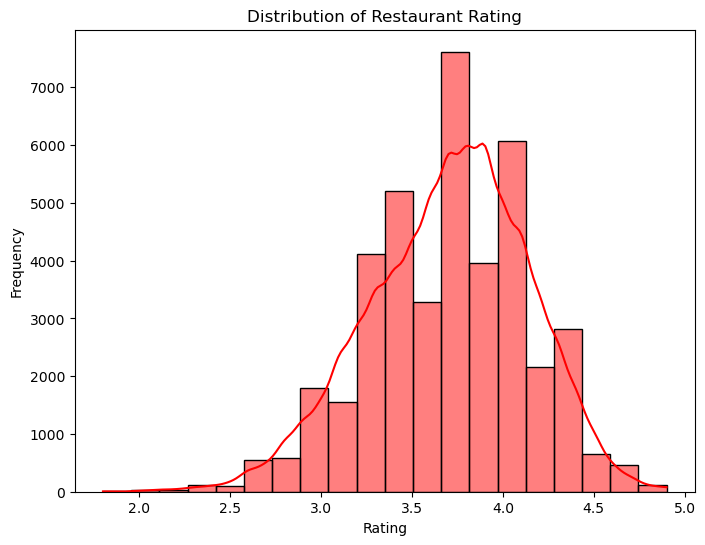

In [17]:
plt.figure(figsize=(8,6))
sns.histplot(df['rate'],bins=20,kde=True,color="red")
plt.title('Distribution of Restaurant Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

- According to the above graph, most restaurant ratings fall between 3.0 and 4.5, indicating that the majority of restaurants are rated as good.

# Online Orders vs Ratings

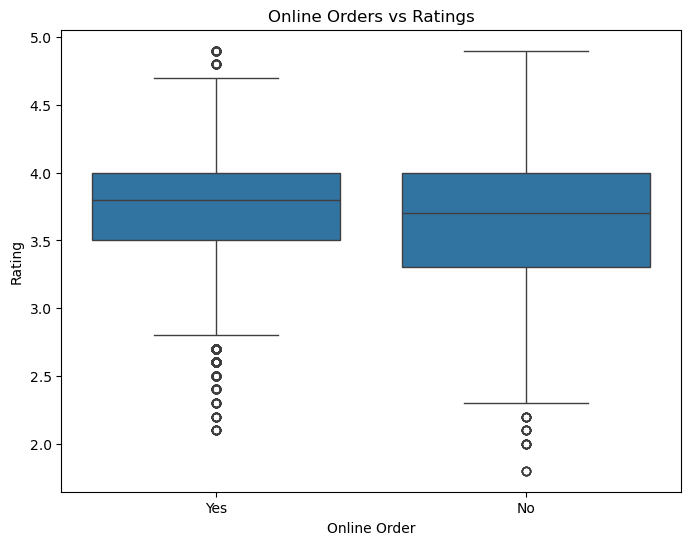

In [18]:
plt.figure(figsize=(8,6))
sns.boxplot(x='online_order',y='rate',data=df)
plt.title('Online Orders vs Ratings')
plt.xlabel('Online Order')
plt.ylabel('Rating')
plt.show()

- Online ordering facilities are available in Bangalore and demonstrate better performance. Some customers give extreme ratings to restaurants based on their food delivery experience.

# Table Booking vs Ratings

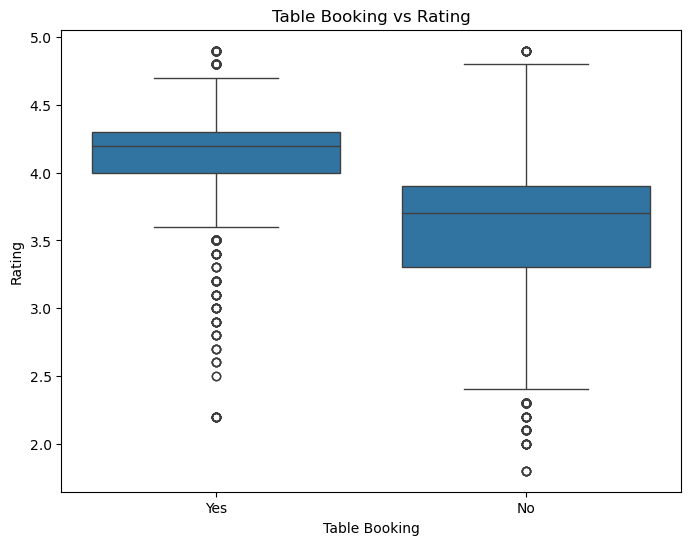

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(x='book_table',y='rate', data=df)
plt.title('Table Booking vs Rating')
plt.xlabel('Table Booking')
plt.ylabel('Rating')
plt.show()

- The availability of table booking facilities is associated with higher restaurant ratings.

# Restaurant Types Distribution

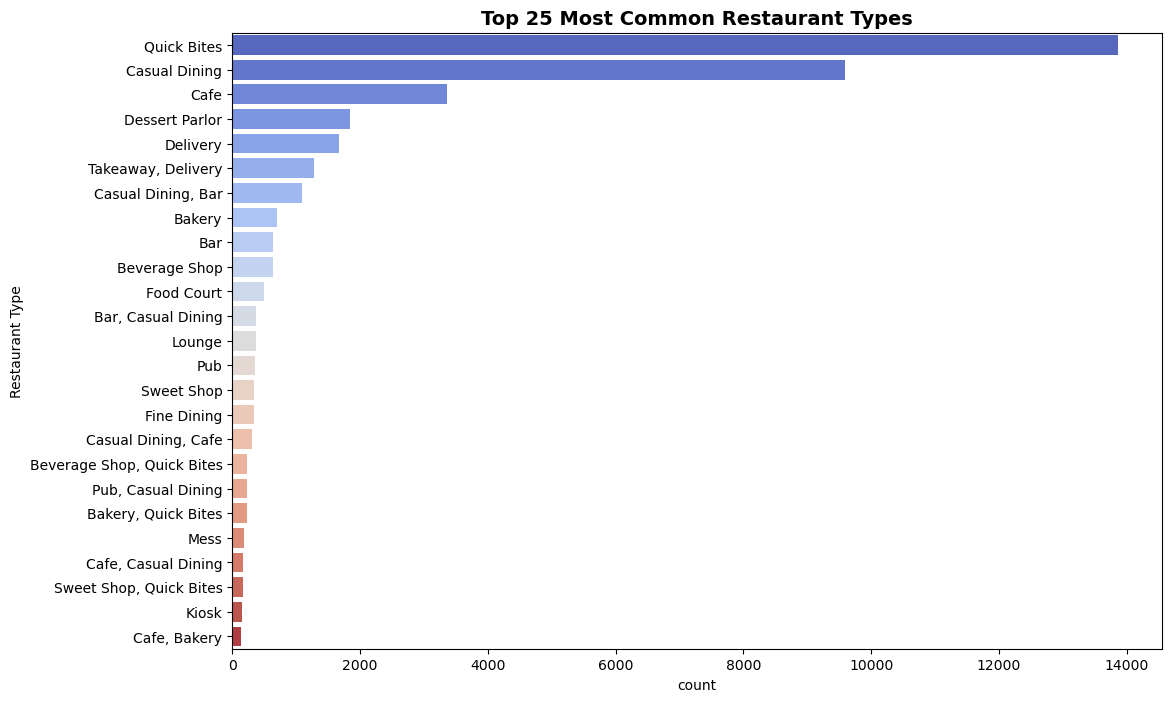

In [20]:
# Get top 25 most common restaurant type
top25 = df['rest_type'].value_counts().nlargest(25).index

#Filter 
df_top = df[df['rest_type'].isin(top25)]
plt.figure(figsize=(12,8))
sns.countplot(
    y='rest_type',
    data=df_top,
    order=top25,
    palette='coolwarm'
)

plt.title("Top 25 Most Common Restaurant Types",fontsize=14,fontweight='bold')
plt.xlabel('count')
plt.ylabel('Restaurant Type')

plt.yticks(fontsize=10)
plt.show()

- Quick Bites is the most common restaurant type, followed by Casual Dining. Hence, opening a Quick Bites restaurant in Bangalore would be preferable, with Casual Dining as the next option.

# Pie Chart of Online Order Availability

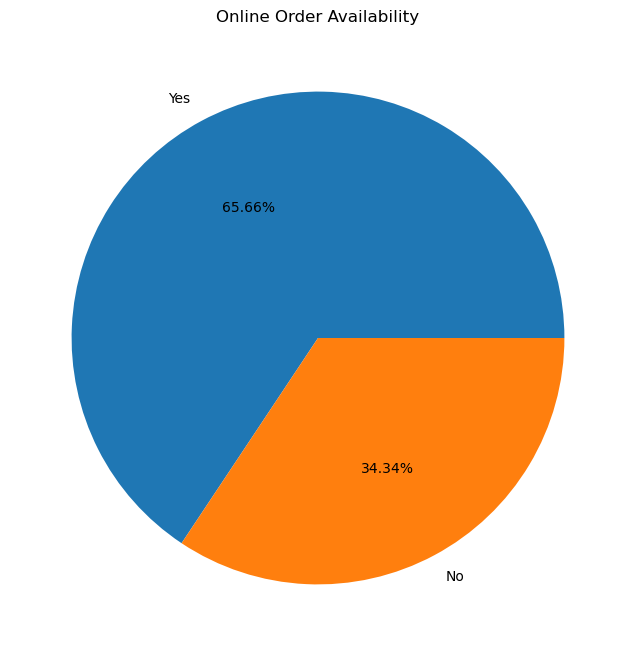

In [21]:
plt.figure(figsize=(8,8))
count = df['online_order'].value_counts()
plt.pie(count.values,labels=count.index,autopct='%.2f%%')
plt.title("Online Order Availability")
plt.show()

- The majority of orders come from online platforms.

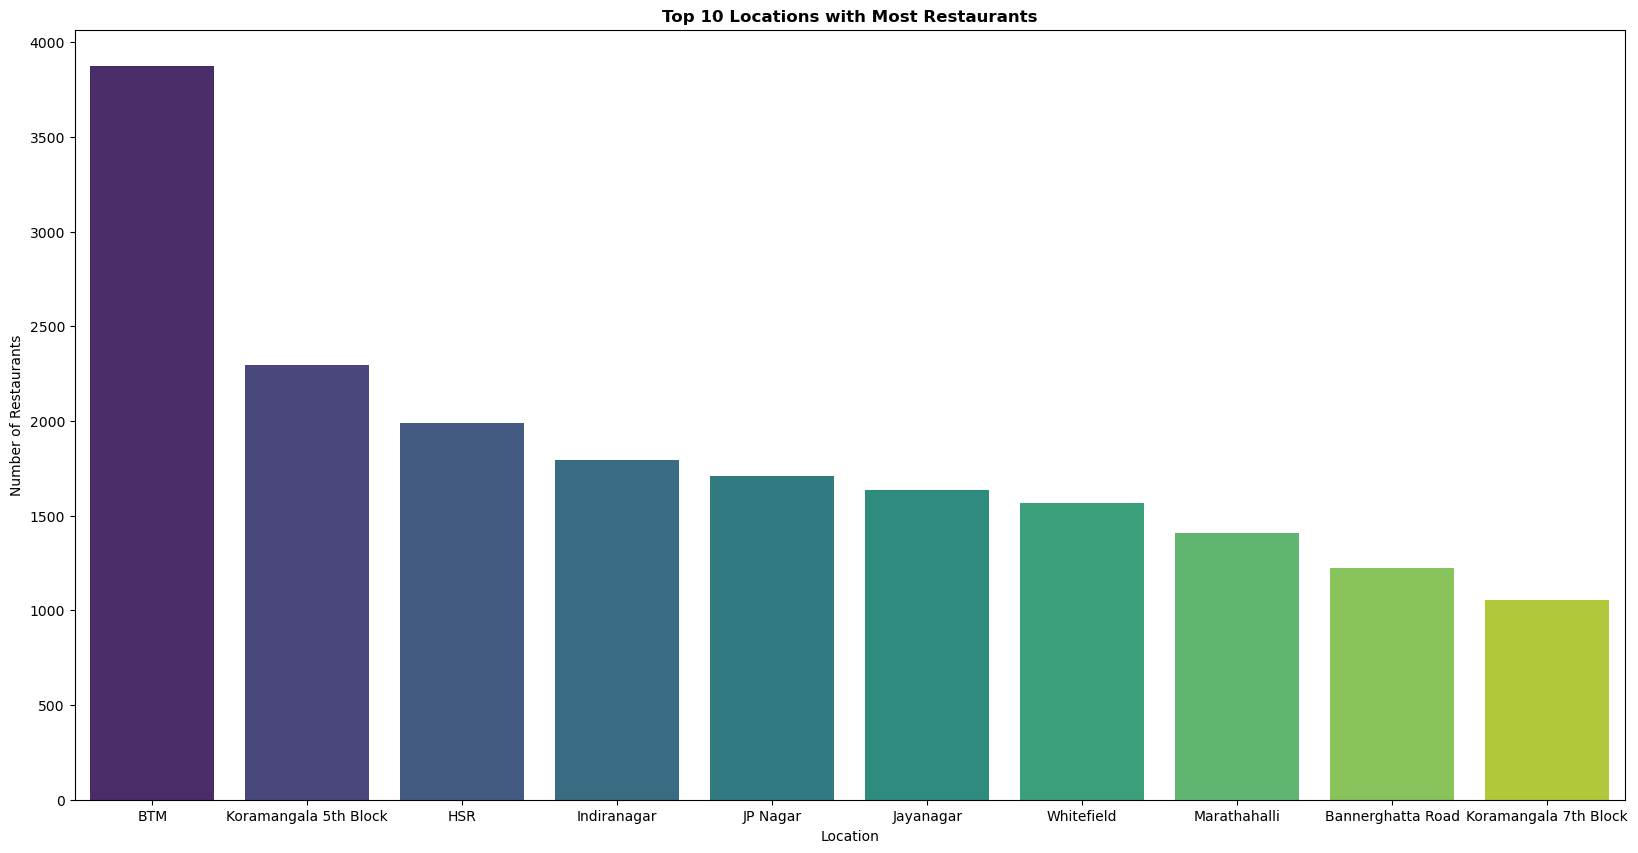

In [27]:
# Get the top 10 locations with the restaurants
top10 = df['location'].value_counts().nlargest(10).index

# Filter dataset for only this locations
df_top = df[df['location'].isin(top10)]

plt.figure(figsize=(20,10))
sns.countplot(x='location',data=df_top,order=top10,palette='viridis')
plt.title("Top 10 Locations with Most Restaurants", fontweight='bold')
plt.xlabel("Location")
plt.ylabel("Number of Restaurants")
plt.show()

In [ ]:
- BTM has the highest number of restaurants compared to other locations.